  IRIS DATASET — BASIC INSPECTION

 Shape        : (150, 5)  (rows, columns)

 Column Names : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

 First 5 Rows (.head()):
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

 Dataset Info (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null   

/tmp/ipykernel_5786/3489551906.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_5786/3489551906.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_5786/3489551906.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(



✅ Plot saved as: /content/iris_eda.png


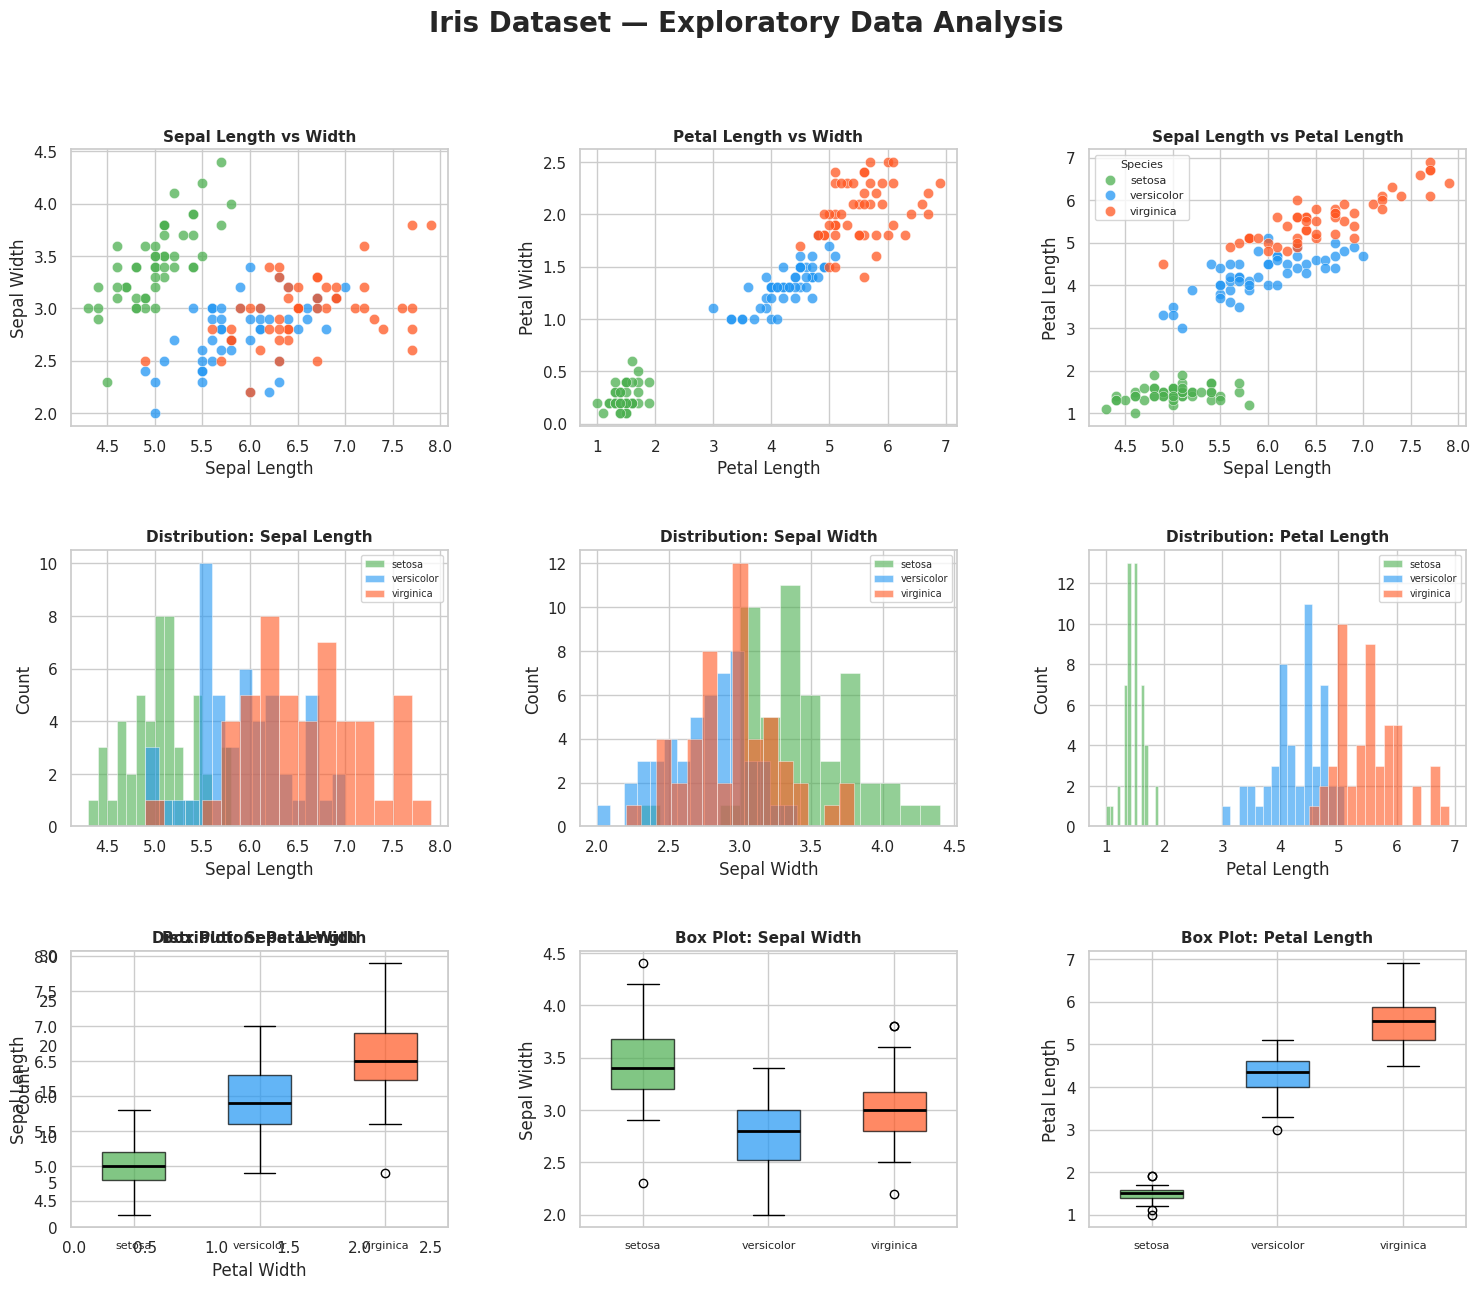

In [ ]:
"""
Task 1: Exploring and Visualizing the Iris Dataset
=====================================================
Libraries: pandas, seaborn, matplotlib

Works in both Jupyter Notebook and .py script
"""

# ── 1. Imports ──────────────────────────────────────────────────────────────
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 2. Load Dataset ──────────────────────────────────────────────────────────
df = sns.load_dataset("iris")   # downloads automatically via seaborn

# ── 3. Basic Inspection ───────────────────────────────────────────────────────
print("=" * 55)
print("  IRIS DATASET — BASIC INSPECTION")
print("=" * 55)

print(f"\n Shape        : {df.shape}  (rows, columns)")
print(f"\n Column Names : {df.columns.tolist()}")

print("\n First 5 Rows (.head()):")
print(df.head())

print("\n Dataset Info (.info()):")
df.info()

print("\n Descriptive Statistics (.describe()):")
print(df.describe().round(2))

print("\n Species Distribution:")
print(df["species"].value_counts())

# ── 4. Visualizations ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Set2")
palette = {"setosa": "#4CAF50", "versicolor": "#2196F3", "virginica": "#FF5722"}

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Iris Dataset — Exploratory Data Analysis",
             fontsize=20, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 4a. Scatter Plots ─────────────────────────────────────────────────────────
scatter_pairs = [
    ("sepal_length", "sepal_width",  "Sepal Length vs Width"),
    ("petal_length", "petal_width",  "Petal Length vs Width"),
    ("sepal_length", "petal_length", "Sepal Length vs Petal Length"),
]

for i, (x, y, title) in enumerate(scatter_pairs):
    ax = fig.add_subplot(gs[0, i])
    for species, color in palette.items():
        subset = df[df["species"] == species]
        ax.scatter(subset[x], subset[y], label=species, color=color,
                   alpha=0.75, edgecolors="white", linewidths=0.4, s=55)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(x.replace("_", " ").title())
    ax.set_ylabel(y.replace("_", " ").title())
    if i == 2:
        ax.legend(fontsize=8, title="Species", title_fontsize=8)

# ── 4b. Histograms ────────────────────────────────────────────────────────────
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

for j, feat in enumerate(features):
    ax = fig.add_subplot(gs[1, j] if j < 3 else gs[2, 0])
    for species, color in palette.items():
        subset = df[df["species"] == species]
        ax.hist(subset[feat], bins=15, alpha=0.60, color=color,
                label=species, edgecolor="white", linewidth=0.5)
    ax.set_title(f"Distribution: {feat.replace('_', ' ').title()}",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(feat.replace("_", " ").title())
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

# ── 4c. Box Plots ─────────────────────────────────────────────────────────────
for k, feat in enumerate(features[:3]):
    ax = fig.add_subplot(gs[2, k])
    bp = ax.boxplot(
        [df[df["species"] == s][feat].values for s in palette],
        labels=list(palette.keys()),
        patch_artist=True,
        notch=False,
        widths=0.5,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, color in zip(bp["boxes"], list(palette.values())):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(f"Box Plot: {feat.replace('_', ' ').title()}",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel(feat.replace("_", " ").title())
    ax.tick_params(axis="x", labelsize=8)

# ── 5. Save & Show ────────────────────────────────────────────────────────────
# os.getcwd() works in both Jupyter Notebook and normal .py scripts
save_path = os.path.join(os.getcwd(), "iris_eda.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
print(f"\n Plot saved as: {save_path}")
plt.show()